In [ ]:
# If you do not use colab. You should install these packages.
# !pip install numpy
# !pip install pandas
# !pip install matplotlib
# !pip install scikit-learn
# !pip install graphviz

In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [2]:
from model.metrics import accuracy,logloss
from model.gradients import logloss_sigmoid_grad
from model.utils import *
from model.activations import sigmoid
import matplotlib.pyplot as plt
seed=42
np.random.seed(seed)

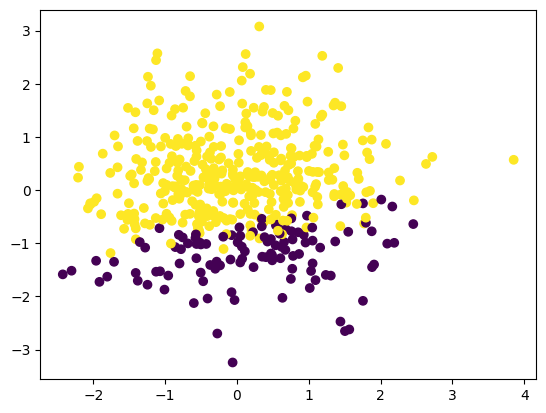

In [3]:
# Sample Code for generating datasets
size=500
seed=42
dim=2
noise_bound = 0.2
np.random.seed(seed)
X,y,W = generate_linear_dataset(size,dim,noise_bound=noise_bound,is_reg=False)
plt.scatter(X[:,1],X[:,2],c=y)

In [4]:
loaded_data = np.load(f'data/logistic_data_A.npz')

# 從裡面把變數拿出來 (對應上面儲存時的名稱)
X = loaded_data['X_data']
y = loaded_data['y_data']
W = loaded_data['W_data']
print(f"X size : {X.shape}, y size : {y.shape}")
size = X.shape[0]
dim = X.shape[1]-1

X size : (2000, 3), y size : (2000,)


# Customized Logistic Regression

In [5]:
from model.linear_model import LinearModel

## Gradient Descent, no L2

20. Training loss: 0.9077189149774242, Val loss:0.8880280218470931
40. Training loss: 0.8613468789250991, Val loss:0.8433521087254656
60. Training loss: 0.818558327113783, Val loss:0.8021971570251782
80. Training loss: 0.7792046129767833, Val loss:0.7644153833220033
100. Training loss: 0.7431075071884357, Val loss:0.7298290373265036
120. Training loss: 0.7100667203139919, Val loss:0.6982380407390826
140. Training loss: 0.6798678306460889, Val loss:0.6694280480017794
160. Training loss: 0.6522899014667848, Val loss:0.6431782047501629
180. Training loss: 0.6271122282886014, Val loss:0.6192680318215016
200. Training loss: 0.6041198691024379, Val loss:0.5974830717339982
220. Training loss: 0.583107822055806, Val loss:0.5776191475337632
240. Training loss: 0.5638838860821457, Val loss:0.5594852616534615
260. Training loss: 0.5462703545582894, Val loss:0.5429052856041352
280. Training loss: 0.5301047515862087, Val loss:0.5277186579571718
300. Training loss: 0.5152398361301339, Val loss:0.513

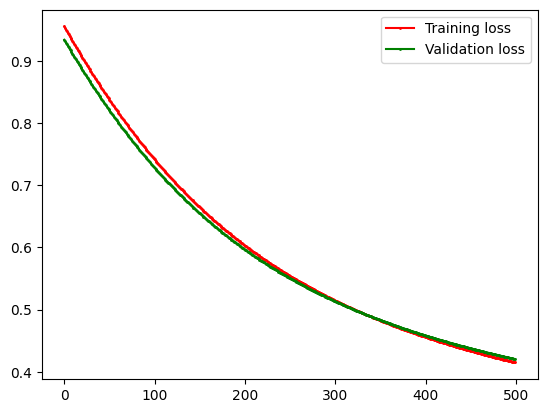

In [6]:
loss_fn = logloss
act_fn = sigmoid
grad_fn = logloss_sigmoid_grad
X_train,y_train,X_val,y_val = get_train_val(X,y)
model = LinearModel(dim,False,loss_fn,grad_fn,act_fn)
model.fit(X_train,y_train,lr=0.01,n_iteration =500,val_ratio=0.2)

In [7]:

y_pred = model.predict(X_val)
print(accuracy(y_val,y_pred))

0.8875


Plot validation set and decision boundary

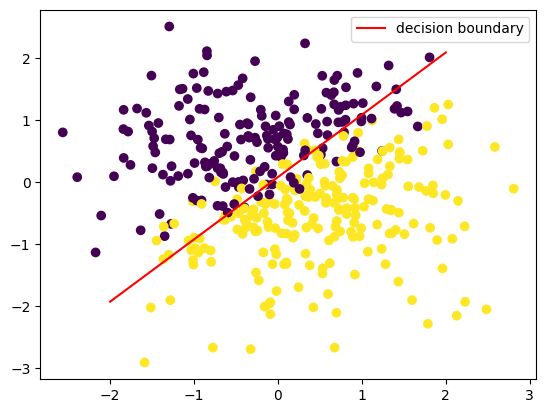

In [8]:
plt.scatter(X_val[:,1],X_val[:,2],c=y_val)

ex1 = np.linspace(-2, 2, 100)
ex2 = -(model.W[1] * ex1 + model.W[0]) / model.W[2]

plt.plot(ex1, ex2, color='r', label='decision boundary')
plt.legend()
plt.show()